In [169]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

data_path = Path("../data/raw/churn.csv")

if not data_path.exists():
    data_path = Path("data/raw/churn.csv")

df_raw = pd.read_csv(data_path)
df = df_raw.copy()

print( "nb ligne et columnes",df.shape)

df.head()

nb ligne et columnes (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [170]:
overview = pd.DataFrame({
    "type": df.dtypes.astype(str),
    "valeurs_manquantes": df.isna().sum(),
    "valeurs_uniques": df.nunique(),
})

overview

,type,valeurs_manquantes,valeurs_uniques
customerID,str,0,7043
gender,str,0,2
SeniorCitizen,int64,0,2
Partner,str,0,3
Dependents,str,0,2
tenure,int64,0,73
PhoneService,str,0,2
MultipleLines,str,0,3
InternetService,str,0,3
OnlineSecurity,str,0,3


In [171]:
missing_before = df.isna().sum()

# Remplacer les chaînes vides ou composées uniquement d'espaces.
df = df.replace(r"^\s*$", pd.NA, regex=True)

missing_after = df.isna().sum()

pd.DataFrame({
    "avant": missing_before,
    "apres_detection_des_espaces": missing_after,
}).sort_values("apres_detection_des_espaces", ascending=False)

,avant,apres_detection_des_espaces
TotalCharges,0,11
Contract,1,1
Partner,0,1
customerID,0,0
gender,0,0
Dependents,0,0
SeniorCitizen,0,0
tenure,0,0
PhoneService,0,0
OnlineSecurity,0,0


In [172]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="raise")

missing_total = df["TotalCharges"].isna()

print("TotalCharges manquants :", missing_total.sum())
df.loc[missing_total, ["tenure", "MonthlyCharges", "TotalCharges"]]

TotalCharges manquants : 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


mainteenant on va analyse les categorie existe =

In [173]:
category_columns = (
    df.drop(columns=["customerID", "Churn"])
    .select_dtypes(include=["object", "string"])
    .columns
)

for column in category_columns:
    print("Colonne :", column)
    print(df[column].value_counts(dropna=False))
    print()

print("SeniorCitizen :")
print(df["SeniorCitizen"].value_counts(dropna=False))

Colonne : gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Colonne : Partner
Partner
No     3641
Yes    3401
NaN       1
Name: count, dtype: int64

Colonne : Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Colonne : PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

Colonne : MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Colonne : InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Colonne : OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

Colonne : OnlineBackup
OnlineBackup
No                     3087
Yes                    2429
No internet service    1526
ajmnxx                    1
Name: count, dtype: int64

Colonne : DeviceProtection
DeviceProtection
No                   

In [174]:
expected_backup_values = ["Yes", "No", "No internet service"]

invalid_backup = (
    df["OnlineBackup"].notna()
    & ~df["OnlineBackup"].isin(expected_backup_values)
)

print("Valeurs inattendues dans OnlineBackup :", invalid_backup.sum())
df.loc[invalid_backup, ["InternetService", "OnlineBackup", "OnlineSecurity"]]

Valeurs inattendues dans OnlineBackup : 1


,InternetService,OnlineBackup,OnlineSecurity
17,Fiber optic,ajmnxx,Yes


In [175]:
print("Lignes dupliquées :", df.duplicated().sum())
print("Identifiants manquants :", df["customerID"].isna().sum())
print("Identifiants répétés :", df["customerID"].duplicated().sum())

numeric_columns = ["tenure", "MonthlyCharges", "TotalCharges"]

print("Valeurs négatives :")
print((df[numeric_columns] < 0).sum())

print("Clients avec MonthlyCharges = 0 :")
df.loc[
    df["MonthlyCharges"] == 0,
    ["tenure", "MonthlyCharges", "TotalCharges", "Contract"],
]

Lignes dupliquées :

 0
Identifiants manquants : 0
Identifiants répétés : 0
Valeurs négatives :
tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64
Clients avec MonthlyCharges = 0 :


,tenure,MonthlyCharges,TotalCharges,Contract
13,49,0.0,5036.3,NaN


,clients,pourcentage
Churn,,
No,5174,73.46
Yes,1869,26.54


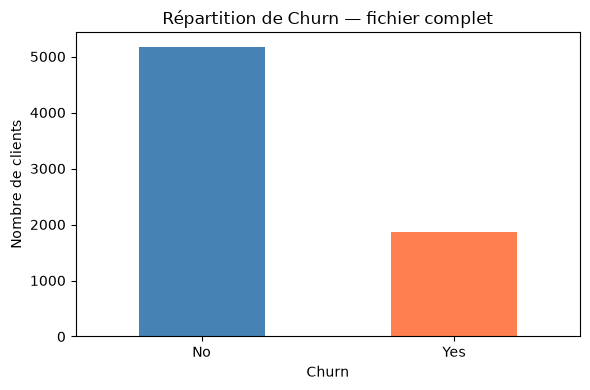

In [176]:
churn_counts = df["Churn"].value_counts()
churn_percent = df["Churn"].value_counts(normalize=True) * 100

display(pd.DataFrame({
    "clients": churn_counts,
    "pourcentage": churn_percent.round(2),
}))

churn_counts.plot.bar(color=["steelblue", "coral"], figsize=(6, 4))
plt.title("Répartition de Churn — fichier complet")
plt.xlabel("Churn")
plt.ylabel("Nombre de clients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [177]:
from sklearn.model_selection import train_test_split

# Ces contrôles évitent de séparer plusieurs lignes d'un même client.
assert df["customerID"].notna().all()
assert df["customerID"].is_unique
assert df["Churn"].isin(["No", "Yes"]).all()

df_train, df_test = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["Churn"],
)

print("Clients pour l'entraînement :", len(df_train))
print("Clients réservés au test :", len(df_test))

Clients pour l'entraînement : 5634
Clients réservés au test : 1409


,tenure,MonthlyCharges,TotalCharges
count,5634.00,5634.00,5626.00
mean,32.49,64.91,2302.60
std,24.57,30.15,2279.17
min,0.00,0.00,18.85
25%,9.00,35.61,407.28
50%,29.00,70.47,1398.12
75%,55.00,90.00,3838.61
max,72.00,118.75,8684.80


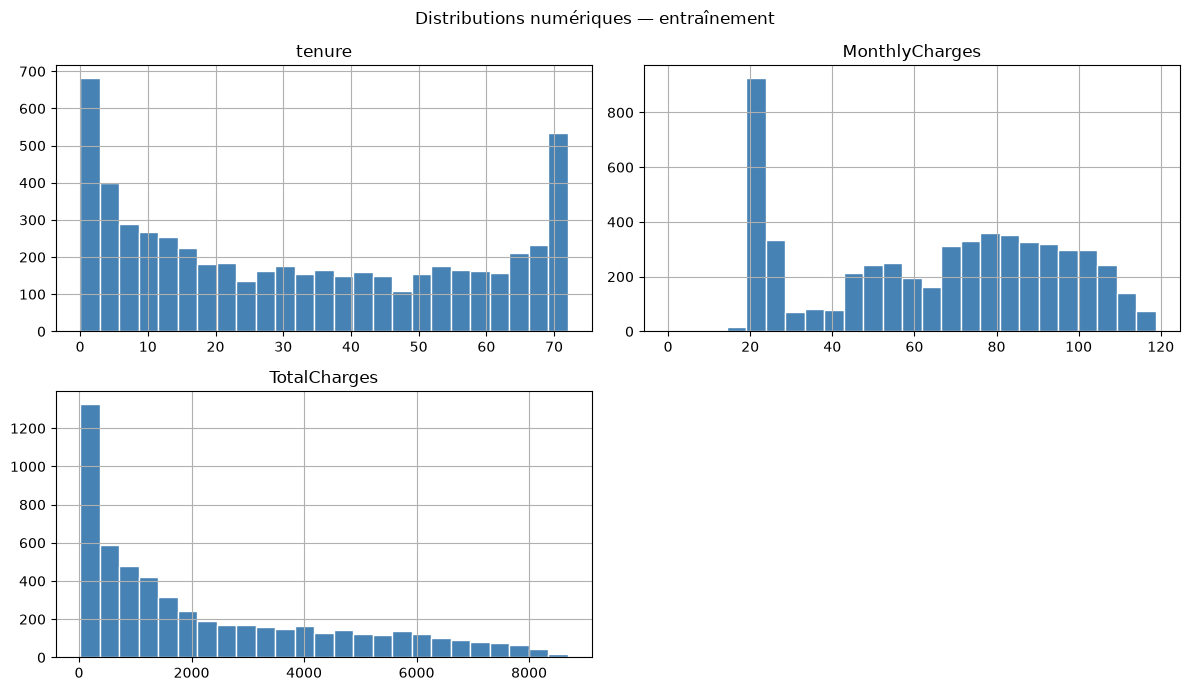

In [178]:
display(df_train[numeric_columns].describe().round(2))

df_train[numeric_columns].hist(
    bins=25,
    figsize=(12, 7),
    color="steelblue",
    edgecolor="white",
)
plt.suptitle("Distributions numériques — entraînement")
plt.tight_layout()
plt.show()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,64.40,1691.9
Yes,10.0,79.95,740.3


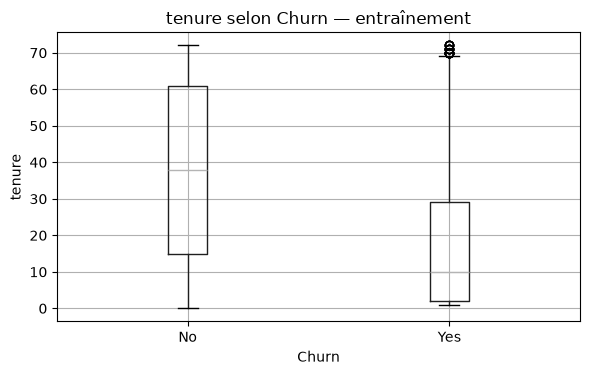

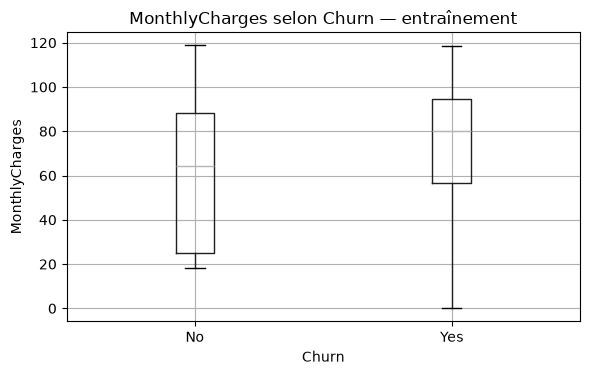

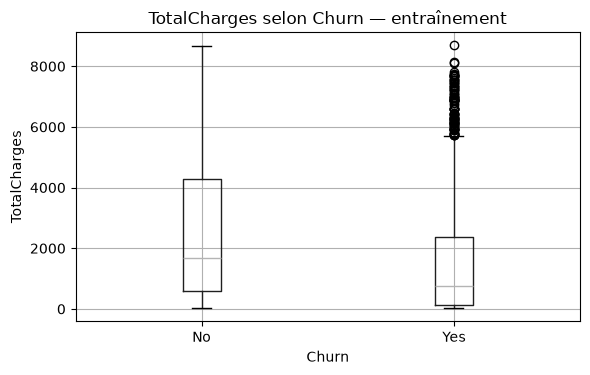

In [179]:
display(df_train.groupby("Churn")[numeric_columns].median().round(2))

for column in numeric_columns:
    df_train.boxplot(column=column, by="Churn", figsize=(6, 4))
    plt.title(column + " selon Churn — entraînement")
    plt.suptitle("")
    plt.xlabel("Churn")
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

In [180]:
df_train = df_train.copy()
df_train["churn_flag"] = df_train["Churn"].map({"No": 0, "Yes": 1})

contract_summary = (
    df_train.groupby("Contract", dropna=False)["churn_flag"]
    .agg(["count", "mean"])
)

contract_summary.columns = ["clients", "taux_churn"]
contract_summary["taux_churn"] = contract_summary["taux_churn"] * 100
contract_summary.round(2)

,clients,taux_churn
Contract,,
Month-to-month,3101,42.73
One year,1173,11.08
Two year,1359,2.87
NaN,1,100.00


Contract


,clients,taux_churn
Contract,,
Month-to-month,3101,42.73
One year,1173,11.08
Two year,1359,2.87
NaN,1,100.00


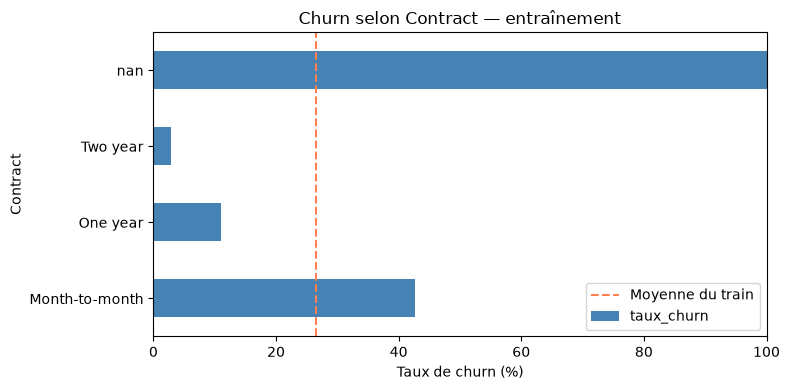

InternetService


,clients,taux_churn
InternetService,,
DSL,1937,18.69
Fiber optic,2483,42.09
No,1214,7.25


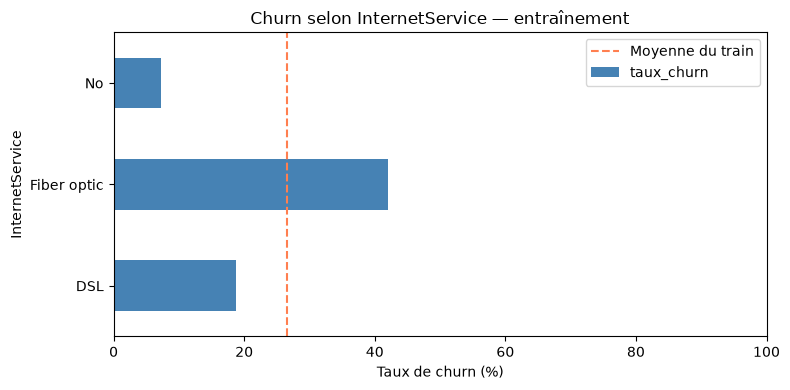

PaymentMethod


,clients,taux_churn
PaymentMethod,,
Bank transfer (automatic),1244,16.16
Credit card (automatic),1213,14.92
Electronic check,1891,45.74
Mailed check,1286,19.28


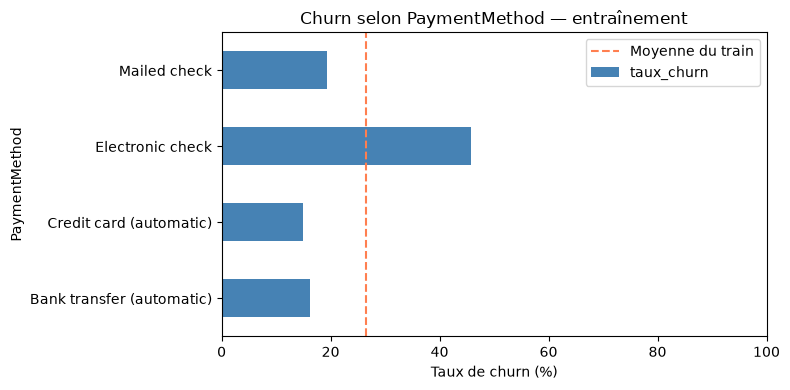

In [181]:
train_churn_rate = df_train["churn_flag"].mean() * 100

for column in ["Contract", "InternetService", "PaymentMethod"]:
    summary = df_train.groupby(column, dropna=False)["churn_flag"].agg(["count", "mean"])
    summary.columns = ["clients", "taux_churn"]
    summary["taux_churn"] = summary["taux_churn"] * 100

    print(column)
    display(summary.round(2))

    summary["taux_churn"].plot.barh(figsize=(8, 4), color="steelblue")
    plt.axvline(train_churn_rate, color="coral", linestyle="--", label="Moyenne du train")
    plt.title("Churn selon " + column + " — entraînement")
    plt.xlabel("Taux de churn (%)")
    plt.xlim(0, 100)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [182]:
df_train[numeric_columns + ["churn_flag"]].corr().round(2)

,tenure,MonthlyCharges,TotalCharges,churn_flag
tenure,1.00,0.26,0.83,-0.35
MonthlyCharges,0.26,1.00,0.65,0.20
TotalCharges,0.83,0.65,1.00,-0.19
churn_flag,-0.35,0.20,-0.19,1.00


In [183]:
print("Clients :", len(df))
print("Churn global (%) :", round(churn_percent["Yes"], 2))
print("TotalCharges manquants :", df["TotalCharges"].isna().sum())
print("Partner manquants :", df["Partner"].isna().sum())
print("Contract manquants :", df["Contract"].isna().sum())
print("OnlineBackup invalides :", invalid_backup.sum())
print("MonthlyCharges égaux à zéro :", (df["MonthlyCharges"] == 0).sum())
print("Doublons complets :", df.duplicated().sum())

print("Taux de churn (%) des contrats mensuels et de deux ans dans le train :")
print(contract_summary.loc[["Month-to-month", "Two year"]].round(2))

Clients : 7043
Churn global (%) : 26.54
TotalCharges manquants : 11
Partner manquants : 1
Contract manquants : 1
OnlineBackup invalides : 1
MonthlyCharges égaux à zéro : 1
Doublons complets : 0
Taux de churn (%) des contrats mensuels et de deux ans dans le train :
                clients  taux_churn
Contract                           
Month-to-month     3101       42.73
Two year           1359        2.87
